In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from dotenv import find_dotenv, load_dotenv
from langchain_openai import ChatOpenAI

_ = load_dotenv(find_dotenv())

llm = ChatOpenAI(
    model="gpt-5.6-luna",
    use_responses_api=True, #known bug in LangChain for Luna.
    reasoning={"effort": "low"},  #The reasoning is medium by default so set this to l
)

In [3]:
from deepagents.backends import FilesystemBackend
from deepagents.middleware.filesystem import FilesystemMiddleware
from deepagents.middleware.skills import SkillsMiddleware
from IPython.display import Image, Markdown, display
from langchain.agents import create_agent
from langchain.messages import HumanMessage
from langchain.tools import tool


In [ ]:
@tool
def get_weather(location: str) -> str:
    """
    Get the weather for a given location
    """
    return f"The weather in {location} is sunny"

@tool
def get_exchange_rate(currency_from: str, currency_to: str) -> str:
    """
    Get the exchange rate between two currencies
    """
    return f"The exchange rate for {currency_from} to {currency_to} is 1.00"


backend = FilesystemBackend(
    root_dir="../",
    virtual_mode=True,
)

agent = create_agent(
    model=llm,
    tools=[get_weather, get_exchange_rate],
    middleware=[
        # Skill discovery + prompt injection
        SkillsMiddleware(
            backend=backend,
            sources=["./skills/"],
        ),

        # Give the model ONLY read_file
        FilesystemMiddleware(
            backend=backend,
            tools=["read_file"],
            system_prompt=None,
        ),
    ],
)

In [ ]:
response = agent.invoke({"messages":[HumanMessage(content="What is the weather in Singapore?")]})

In [ ]:
display(Markdown(response['messages'][-1].content[0]['text']))

Singapore is currently **sunny**. It’s a good time for outdoor plans—though a water bottle and sun protection are still advisable.

## Remote skill loading
> Use `create_file_data`

In [5]:
from deepagents.backends import StateBackend

In [ ]:
from urllib.request import urlopen
from deepagents import create_deep_agent
from deepagents.backends.utils import create_file_data
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()
backend = StateBackend()

skill_url = "https://raw.githubusercontent.com/langchain-ai/deepagents/refs/heads/main/libs/cli/examples/skills/langgraph-docs/SKILL.md"
with urlopen(skill_url) as response:
    skill_content = response.read().decode('utf-8')

skills_files = {
    "/skills/langgraph-docs/SKILL.md": create_file_data(skill_content),
}

agent = create_deep_agent(
    model=llm,
    backend=backend,
    skills=["/skills/"],
    checkpointer=checkpointer,
)

result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "What is langgraph?"}],
        # Seed the default StateBackend's in-state filesystem (virtual paths must start with "/").
        "files": skills_files,
    },
    config={"configurable": {"thread_id": "12345"}},
)

In [24]:
display(Markdown(result['messages'][-1].content[-1]['text']))

**LangGraph** is an open-source framework for building **stateful, multi-step applications with large language models (LLMs)**.

It represents an application as a **graph**:

- **Nodes** perform actions, such as calling an LLM, running a tool, or executing custom code.
- **Edges** determine what happens next.
- **State** stores information shared across steps.
- **Conditional routing** lets the workflow make decisions.
- **Persistence and checkpoints** allow workflows to pause, resume, and maintain conversation history.
- **Human-in-the-loop steps** allow a person to approve or modify actions.

For example, an agent might follow this graph:

```text
User request
    ↓
Analyze request
    ↓
Need a tool?
 ┌──┴──┐
Yes   No
 ↓     ↓
Call tool  Respond
 ↓
Interpret result
 ↓
Respond
```

LangGraph is useful for building:

- Chatbots with memory
- Tool-using agents
- Research assistants
- Multi-agent systems
- Approval workflows
- Long-running or interruptible processes
- Reliable business process automation

It is related to **LangChain**, but the focus is different:

- **LangChain** provides components for LLM applications—models, prompts, tools, retrievers, and agents.
- **LangGraph** provides the orchestration layer for connecting those components into explicit, controllable, stateful workflows.

A minimal Python example looks like:

```python
from typing import TypedDict
from langgraph.graph import StateGraph

class State(TypedDict):
    message: str

def greet(state: State):
    return {"message": f"Hello, {state['message']}!"}

graph = StateGraph(State)
graph.add_node("greet", greet)
graph.set_entry_point("greet")
graph.set_finish_point("greet")

app = graph.compile()

result = app.invoke({"message": "Ada"})
print(result)
```

In short, **LangGraph is a way to build LLM applications as explicit state machines or workflows rather than relying entirely on opaque agent loops**.

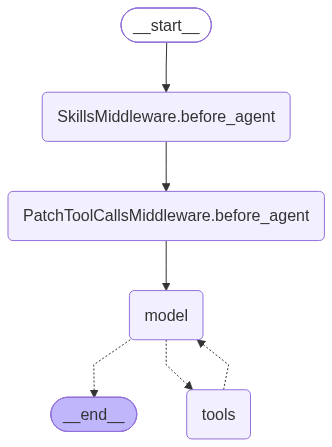

In [ ]:
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

## On a shallow agent

In [6]:
import os
from pathlib import Path

In [ ]:
skills_root = Path("../skills")  # relative to notebook, or use absolute path
skills_dict = {}

for dirpath, _, filenames in os.walk(skills_root):
    for filename in filenames:
        # Match SKILL.md case-insensitively (you have both SKILL.md and SKILL.MD)
        if filename.lower() != "skill.md":
            continue

        filepath = Path(dirpath) / filename
        skill_name = filepath.parent.name  # e.g. "weather-skill"

        with open(filepath, encoding="utf-8") as f:
            markdown_content = f.read()

        # Virtual path used by SkillsMiddleware / FilesystemBackend
        virtual_path = f"/skills/{skill_name}/SKILL.md"

        skills_dict[virtual_path] = create_file_data(markdown_content)

skills_dict

{'/skills/forex-skill/SKILL.md': {'content': '---\nname: forex-skill\ndescription: Get live exchange rates between two currencies. Use this whenever the user asks about currency conversion, exchange rates, how much something costs in another currency, or comparisons like "is the dollar strong right now" — even if they don\'t use the words "forex" or "exchange rate" explicitly (e.g. "how much is 500 SGD in yen", "should I exchange money now or wait"). Always use this instead of guessing from memory, since exchange rates move constantly and Claude\'s training data has no visibility into current rates.\n---\n\n# Forex Skill\n\nFetches the live exchange rate between two currencies and reports it back in a clear, practical format.\n\n## Why this matters\n\nClaude has no live access to current exchange rates — anything it "knows" about today\'s rates from training data is stale or fabricated, and currency markets move by the minute. Always call the `get_exchange_rate` tool below rather than 

In [ ]:
backend = StateBackend()

agent = create_agent(
    model=llm,
    tools=[get_weather, get_exchange_rate],
    middleware=[
        FilesystemMiddleware(backend=backend),
        SkillsMiddleware(
            backend=backend,
            sources=["./skills/"],
        ),
    ],
)

In [34]:
result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "What is the weather in Singapore?"}],
        # Seed the default StateBackend's in-state filesystem (virtual paths must start with "/").
        "files": skills_files,
    },
)

In [35]:
display(Markdown(result['messages'][-1].content[-1]['text']))

Singapore is sunny right now.

## Using shell backends

**What is `virtual_mode`?**

It's a path translation layer that only the filesystem tools speak.

With `virtual_mode=True`, `root_dir` gets presented to the model as if it were `/`. Your actual path/to/skills/weather-skill/SKILL.md shows up to the agent as /skills/weather-skill/SKILL.md. The middleware translates on the way in and out. It also blocks `..` traversal, so read_file can't wander up into your ~/.ssh.

With `virtual_mode=False`, paths are used as-is — agents can access any file using absolute paths. No translator. What the model says is what hits the disk.

In [ ]:
from pathlib import Path

from deepagents.backends import LocalShellBackend
from deepagents.middleware import FilesystemMiddleware, SkillsMiddleware

# --- Backend: gives the agent BOTH file access and shell execution ---
# NOTE: LocalShellBackend is NOT a sandbox — it's subprocess with a lanyard.
# No process isolation, no resource limits. Fine for a notebook on my laptop.
# If this pattern ever goes into production use HITL middleware on the execute 
# tool before shipping

backend = LocalShellBackend(
    root_dir=str(Path.cwd()),           # absolute — no ambiguity about the frame
    virtual_mode=False,                 # ← ONE namespace. read_file and execute
                                        #   now agree on what a path means.
                                        #   virtual_mode gave zero security here
                                        #   anyway (docs are explicit), so all it
                                        #   bought was a split-brain the model had
                                        #   to brute-force its way out of.
    inherit_env=True,                   # simpler than hand-rolling PATH/HOME
)

middleware = [
    FilesystemMiddleware(
        backend=backend,
        tools=["read_file", "ls", "glob", "execute"],
        # ls/glob only make sense once virtual_mode=False — with it on they'd
        # report virtual paths and make the confusion WORSE. Now they give the
        # model a cheap discovery path instead of shelling out to `find`.
        system_prompt=None,
    ),
    SkillsMiddleware(backend=backend, sources=["./skills/"]),
]

agent = create_agent(model=llm, middleware=middleware)

**Sanity checks before trusting any output**
1. Scripts should log to a FILE (skill.log), never print()/stdout — stdout
    is the data channel back to the model, logging into it corrupts the JSON.
2. Don't trust "sunny" as proof of execution — it's the most guessable
    string in English. Use something unguessable (uuid, os.getpid()) when
    testing whether the shell call actually happened vs was hallucinated.
3. Cross-check against LangSmith trace: did `execute` actually get called,
    and what raw string came back? The log file confirms the process ran;
    the trace confirms the model actually used it.

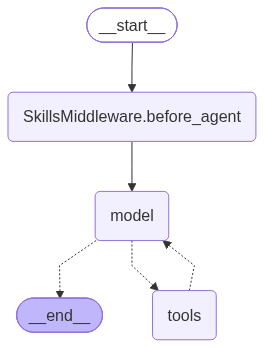

In [7]:
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [8]:
response = agent.invoke(
    {
        "messages":[
            HumanMessage(content="What is the weather in Sydney and Melbourne today?")
        ]
    }
)

In [9]:
display(Markdown(response['messages'][-1].content[-1]['text']))

Today:

- **Sydney:** Sunny
- **Melbourne:** Sunny